# 90 Model Comparison

Use this notebook after running the active `08` model notebooks. It loads the saved metrics, histories, and trajectory prediction exports, then produces the final comparison tables and plots for the current training pipeline.


In [1]:
import gc
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

gc.collect()

PROJECT_ROOT = Path.home() / 'Documents/Thesis'
PIPELINE_ROOT = PROJECT_ROOT / 'model_training'
if str(PIPELINE_ROOT) not in sys.path:
    sys.path.insert(0, str(PIPELINE_ROOT))

RESULTS_ROOT = PIPELINE_ROOT / 'results'
COMPARISON_ROOT = PIPELINE_ROOT / 'comparison_exports'
PLOTS_ROOT = COMPARISON_ROOT / 'plots'
PLOTS_ROOT.mkdir(parents=True, exist_ok=True)

MODEL_SLUGS = [
    'cv_baseline',
    'cnn_lstm',
    'cnn_gnn_lstm',
    'cnn_gnn_transformer',
    'cnn_gnn_lstm_transformer',
]

print('Results root:', RESULTS_ROOT)
print('Comparison plot root:', PLOTS_ROOT)


Results root: /home/basudeo/Documents/Thesis/model_training/results
Comparison plot root: /home/basudeo/Documents/Thesis/model_training/comparison_exports/plots


In [2]:
summary_rows = []
latest_metrics = {}
for slug in MODEL_SLUGS:
    latest_metrics_path = RESULTS_ROOT / slug / 'latest_metrics.json'
    if not latest_metrics_path.exists():
        continue
    payload = json.loads(latest_metrics_path.read_text())
    payload['model'] = slug
    latest_metrics[slug] = payload
    summary_rows.append(payload)

summary_df = pd.DataFrame(summary_rows)
if summary_df.empty:
    raise RuntimeError('No latest_metrics.json files were found. Run the model notebooks first.')

summary_df = summary_df[['model', 'ADE', 'FDE', 'RMSE', 'loss', 'best_epoch', 'timestamp']]
summary_df = summary_df.sort_values('ADE', ascending=True).reset_index(drop=True)
display(summary_df)
print(summary_df.to_string(index=False))

best_model_slug = summary_df.iloc[0]['model']
print('Best model by ADE:', best_model_slug)


,model,ADE,FDE,RMSE,loss,best_epoch,timestamp
0,cnn_gnn_transformer,0.009387,0.006006,0.014377,0.000052,8.0,20260523_115455
1,cnn_gnn_lstm,0.009591,0.007760,0.014742,0.000054,20.0,20260523_112649
2,cnn_lstm,0.009671,0.007310,0.014738,0.000054,9.0,20260523_112308
3,cnn_gnn_lstm_transformer,0.009789,0.007624,0.014402,0.000052,9.0,20260523_120815
4,cv_baseline,0.098831,0.138633,0.164109,0.098831,NaN,20260523_112244


                   model      ADE      FDE     RMSE     loss  best_epoch       timestamp
     cnn_gnn_transformer 0.009387 0.006006 0.014377 0.000052         8.0 20260523_115455
            cnn_gnn_lstm 0.009591 0.007760 0.014742 0.000054        20.0 20260523_112649
                cnn_lstm 0.009671 0.007310 0.014738 0.000054         9.0 20260523_112308
cnn_gnn_lstm_transformer 0.009789 0.007624 0.014402 0.000052         9.0 20260523_120815
             cv_baseline 0.098831 0.138633 0.164109 0.098831         NaN 20260523_112244
Best model by ADE: cnn_gnn_transformer


In [3]:
comparison_csv = COMPARISON_ROOT / 'trajectory_model_summary_latest.csv'
comparison_json = COMPARISON_ROOT / 'trajectory_model_summary_latest.json'
summary_df.to_csv(comparison_csv, index=False)
comparison_json.write_text(summary_df.to_json(orient='records', indent=2))
print('Saved comparison CSV:', comparison_csv)
print('Saved comparison JSON:', comparison_json)


Saved comparison CSV: /home/basudeo/Documents/Thesis/model_training/comparison_exports/trajectory_model_summary_latest.csv
Saved comparison JSON: /home/basudeo/Documents/Thesis/model_training/comparison_exports/trajectory_model_summary_latest.json


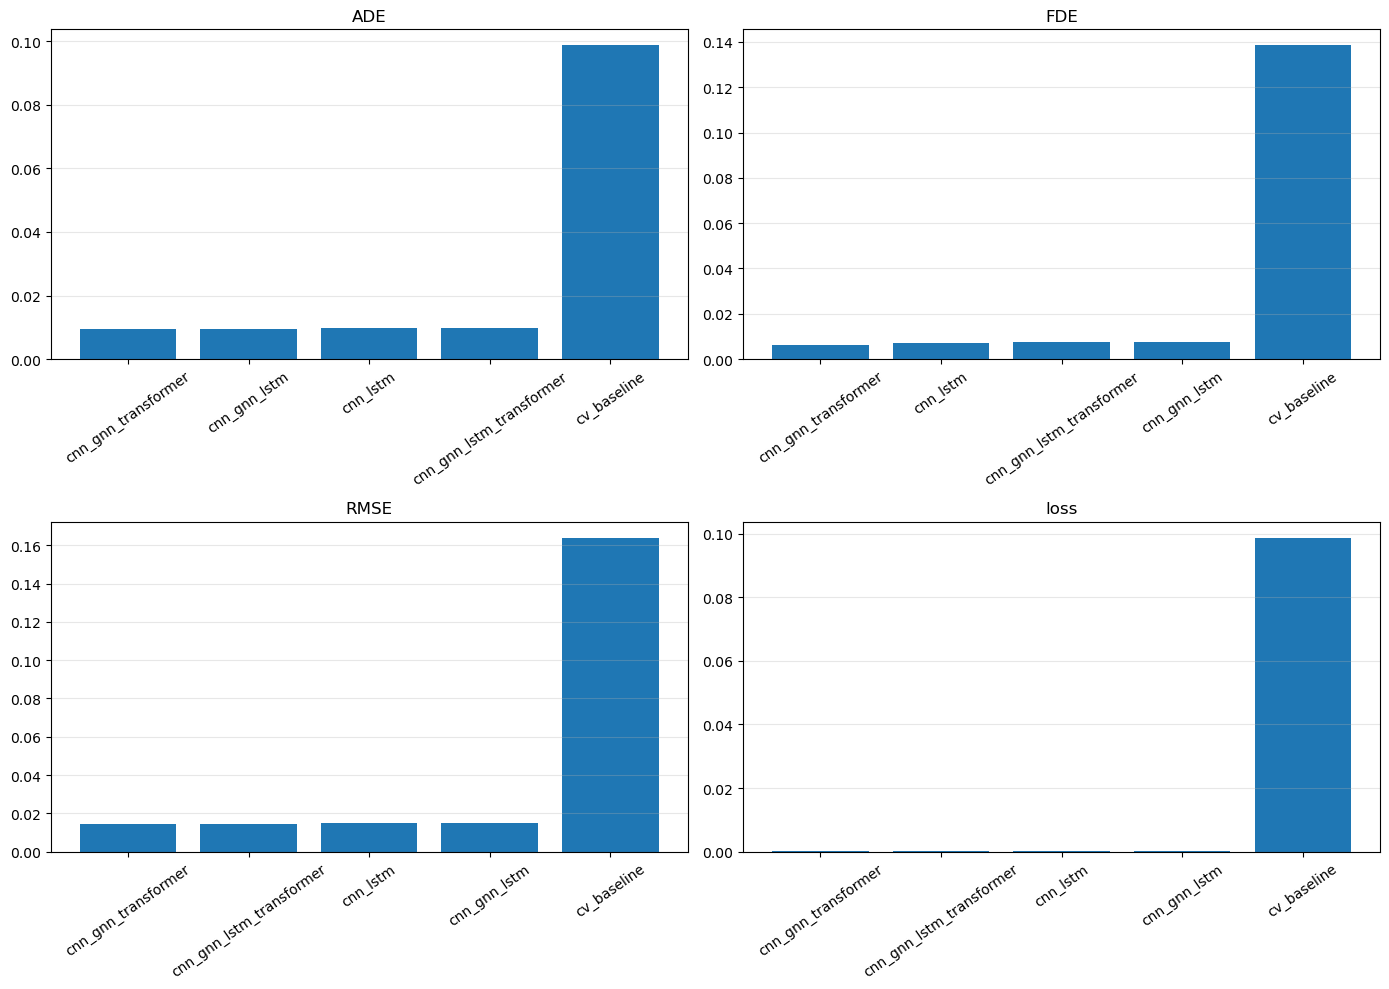

Saved: /home/basudeo/Documents/Thesis/model_training/comparison_exports/plots/trajectory_metric_comparison.png


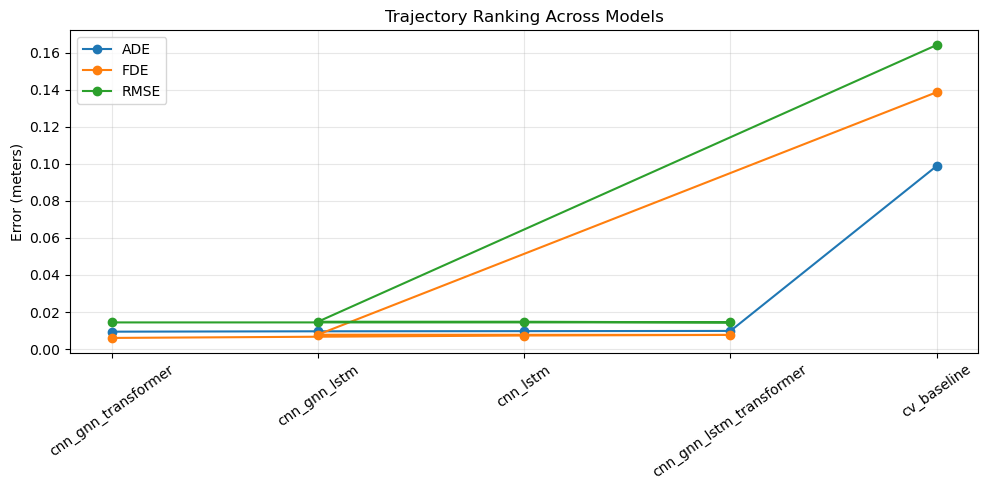

Saved: /home/basudeo/Documents/Thesis/model_training/comparison_exports/plots/trajectory_metric_lines.png


In [4]:
plot_metrics = ['ADE', 'FDE', 'RMSE', 'loss']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric in zip(axes.flatten(), plot_metrics):
    ordered = summary_df.sort_values(metric, ascending=True)
    ax.bar(ordered['model'], ordered[metric])
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=35)
    ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
out_path = PLOTS_ROOT / 'trajectory_metric_comparison.png'
plt.savefig(out_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', out_path)

fig, ax = plt.subplots(figsize=(10, 5))
for metric in ['ADE', 'FDE', 'RMSE']:
    ordered = summary_df.sort_values(metric, ascending=True).reset_index(drop=True)
    ax.plot(ordered['model'], ordered[metric], marker='o', label=metric)
ax.set_title('Trajectory Ranking Across Models')
ax.set_ylabel('Error (meters)')
ax.grid(True, alpha=0.3)
ax.legend()
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
out_path = PLOTS_ROOT / 'trajectory_metric_lines.png'
plt.savefig(out_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', out_path)


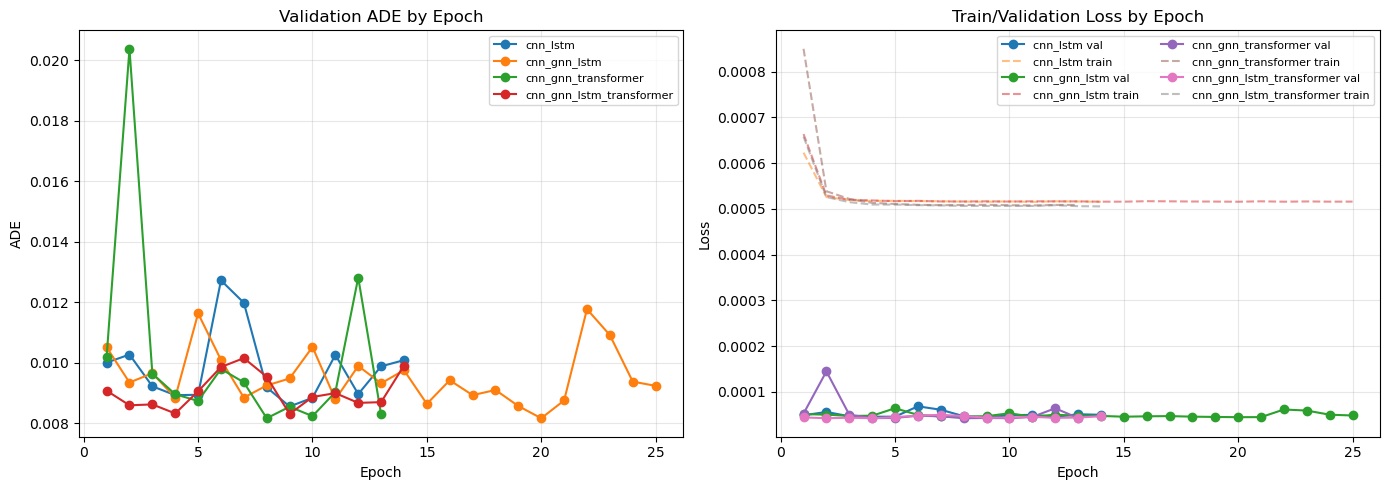

Saved: /home/basudeo/Documents/Thesis/model_training/comparison_exports/plots/training_curve_comparison.png


In [5]:
history_payloads = {}
for slug in MODEL_SLUGS:
    run_dir = RESULTS_ROOT / slug
    history_files = sorted(run_dir.glob('*_training_history.csv'))
    if history_files:
        history_payloads[slug] = pd.read_csv(history_files[-1])

if not history_payloads:
    print('No training history CSV files found.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for slug, history_df in history_payloads.items():
        if {'epoch', 'val_ade'}.issubset(history_df.columns):
            axes[0].plot(history_df['epoch'], history_df['val_ade'], marker='o', label=slug)
        if {'epoch', 'train_loss', 'val_loss'}.issubset(history_df.columns):
            axes[1].plot(history_df['epoch'], history_df['val_loss'], marker='o', label=f'{slug} val')
            axes[1].plot(history_df['epoch'], history_df['train_loss'], linestyle='--', alpha=0.5, label=f'{slug} train')
    axes[0].set_title('Validation ADE by Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('ADE')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)

    axes[1].set_title('Train/Validation Loss by Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=8, ncol=2)

    plt.tight_layout()
    out_path = PLOTS_ROOT / 'training_curve_comparison.png'
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved:', out_path)


Shared sample count across models: 9219


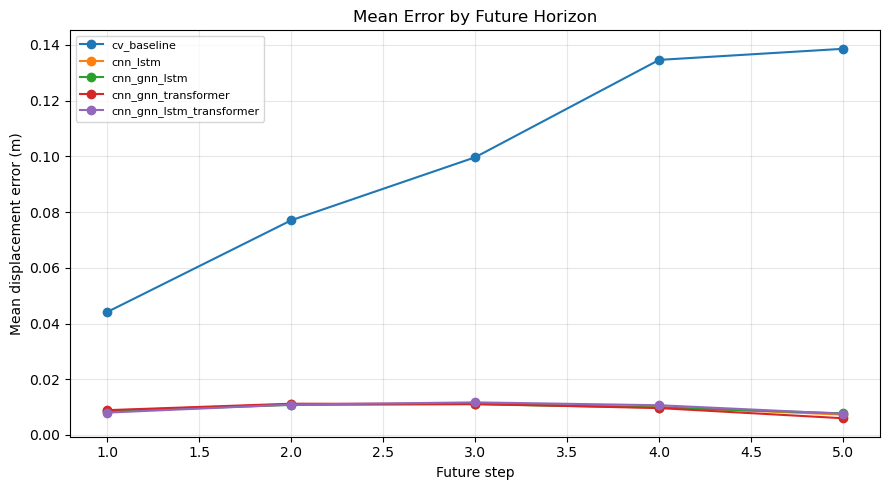

Saved: /home/basudeo/Documents/Thesis/model_training/comparison_exports/plots/future_horizon_error_comparison.png


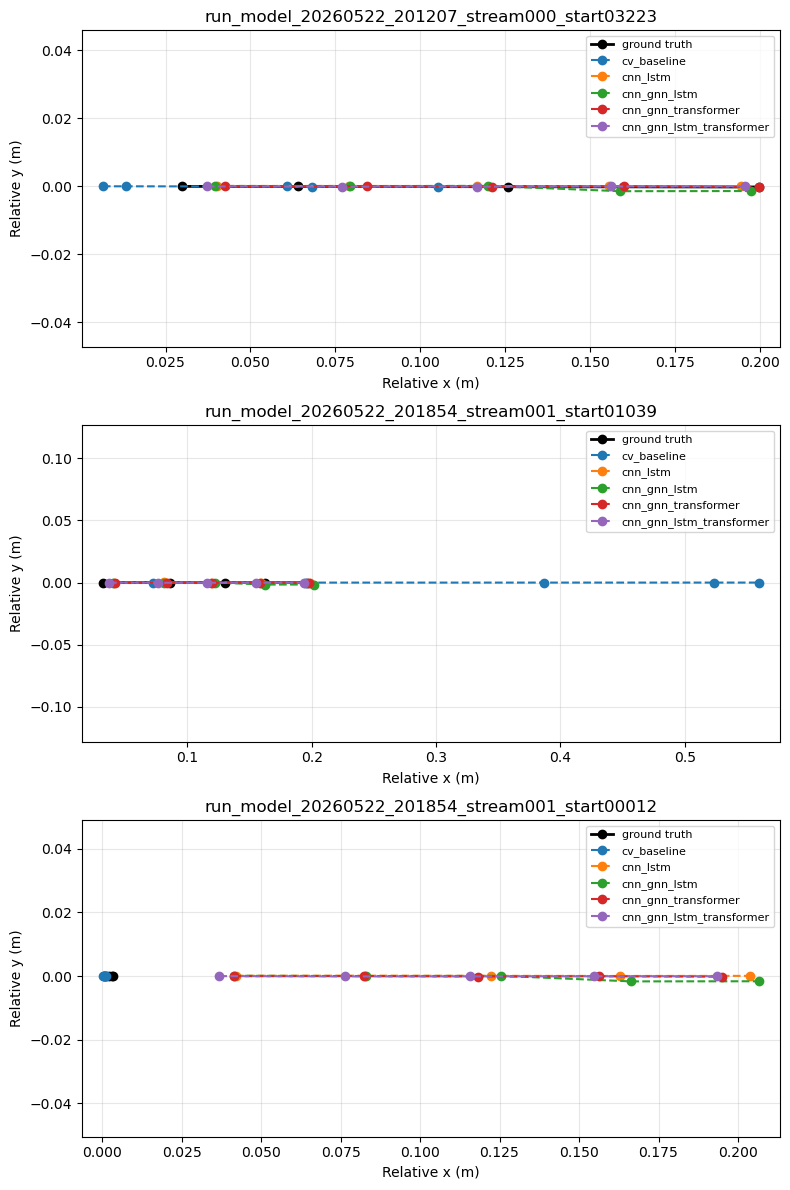

Saved: /home/basudeo/Documents/Thesis/model_training/comparison_exports/plots/shared_sample_trajectory_panel.png


In [6]:
trajectory_exports = {}
for slug in MODEL_SLUGS:
    latest_metrics_path = RESULTS_ROOT / slug / 'latest_metrics.json'
    if not latest_metrics_path.exists():
        continue
    payload = json.loads(latest_metrics_path.read_text())
    pred_path = payload.get('prediction_export_path')
    if not pred_path:
        continue
    npz_path = Path(pred_path)
    if not npz_path.exists():
        continue
    arrays = np.load(npz_path, allow_pickle=False)
    trajectory_exports[slug] = {
        'sample_ids': arrays['sample_ids'].astype(str),
        'pred_future_xy': arrays['pred_future_xy'],
        'true_future_xy': arrays['true_future_xy'],
        'future_dt': arrays['future_dt'],
    }

if len(trajectory_exports) < 2:
    print('Not enough trajectory exports found yet.')
else:
    common_ids = None
    for slug, payload in trajectory_exports.items():
        ids = set(payload['sample_ids'].tolist())
        common_ids = ids if common_ids is None else common_ids.intersection(ids)
    common_ids = sorted(common_ids or [])
    print('Shared sample count across models:', len(common_ids))

    if not common_ids:
        print('No shared sample ids found across saved trajectory exports.')
    else:
        step_rows = []
        for slug, payload in trajectory_exports.items():
            idx_map = {sid: idx for idx, sid in enumerate(payload['sample_ids'])}
            use_idx = [idx_map[sid] for sid in common_ids if sid in idx_map]
            pred = payload['pred_future_xy'][use_idx]
            true = payload['true_future_xy'][use_idx]
            step_error = np.linalg.norm(pred - true, axis=-1).mean(axis=0)
            for step, err in enumerate(step_error, start=1):
                step_rows.append({'model': slug, 'future_step': step, 'mean_error': float(err)})
        step_df = pd.DataFrame(step_rows)
        fig, ax = plt.subplots(figsize=(9, 5))
        for slug in MODEL_SLUGS:
            rows = step_df[step_df['model'] == slug]
            if not rows.empty:
                ax.plot(rows['future_step'], rows['mean_error'], marker='o', label=slug)
        ax.set_title('Mean Error by Future Horizon')
        ax.set_xlabel('Future step')
        ax.set_ylabel('Mean displacement error (m)')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        plt.tight_layout()
        out_path = PLOTS_ROOT / 'future_horizon_error_comparison.png'
        plt.savefig(out_path, dpi=180, bbox_inches='tight')
        plt.show()
        print('Saved:', out_path)

        best_slug = summary_df.iloc[0]['model']
        best_payload = trajectory_exports[best_slug]
        best_map = {sid: idx for idx, sid in enumerate(best_payload['sample_ids'])}
        common_final_errors = []
        for sid in common_ids:
            idx = best_map[sid]
            pred = best_payload['pred_future_xy'][idx, -1]
            true = best_payload['true_future_xy'][idx, -1]
            common_final_errors.append((sid, float(np.linalg.norm(pred - true))))
        common_final_errors.sort(key=lambda item: item[1])
        chosen_ids = []
        if common_final_errors:
            candidate_positions = [0, len(common_final_errors)//2, len(common_final_errors)-1]
            seen = set()
            for pos in candidate_positions:
                sid = common_final_errors[pos][0]
                if sid not in seen:
                    chosen_ids.append(sid)
                    seen.add(sid)

        fig, axes = plt.subplots(len(chosen_ids), 1, figsize=(8, 4 * max(1, len(chosen_ids))))
        axes = np.atleast_1d(axes)
        for ax, sid in zip(axes, chosen_ids):
            true_xy = None
            for slug, payload in trajectory_exports.items():
                idx_map = {sample_id: i for i, sample_id in enumerate(payload['sample_ids'])}
                idx = idx_map[sid]
                if true_xy is None:
                    true_xy = payload['true_future_xy'][idx]
                    ax.plot(true_xy[:, 0], true_xy[:, 1], '-o', color='black', linewidth=2, label='ground truth')
                ax.plot(payload['pred_future_xy'][idx][:, 0], payload['pred_future_xy'][idx][:, 1], '--o', label=slug)
            ax.set_title(sid)
            ax.set_xlabel('Relative x (m)')
            ax.set_ylabel('Relative y (m)')
            ax.axis('equal')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8)
        plt.tight_layout()
        out_path = PLOTS_ROOT / 'shared_sample_trajectory_panel.png'
        plt.savefig(out_path, dpi=180, bbox_inches='tight')
        plt.show()
        print('Saved:', out_path)
